# EDA

In [1]:
import pandas as pd

df = pd.read_csv('../data/ds_salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [2]:
# 不要列削除
df = df.drop(columns=["salary", 'salary_currency'])

In [3]:
# 列の並び替え
df = df[['work_year', 'experience_level', 'employment_type', 
         'job_title', 'employee_residence', 'company_location', 
         'company_size','remote_ratio','salary_in_usd']]

In [4]:
# train_test分割
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

## データ理解（EDA）

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3004 non-null   int64
 1   experience_level    3004 non-null   str  
 2   employment_type     3004 non-null   str  
 3   job_title           3004 non-null   str  
 4   employee_residence  3004 non-null   str  
 5   company_location    3004 non-null   str  
 6   company_size        3004 non-null   str  
 7   remote_ratio        3004 non-null   int64
 8   salary_in_usd       3004 non-null   int64
dtypes: int64(3), str(6)
memory usage: 285.3 KB


In [6]:
train_df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
employee_residence    0
company_location      0
company_size          0
remote_ratio          0
salary_in_usd         0
dtype: int64

In [7]:
train_df.describe()

,work_year,remote_ratio,salary_in_usd
count,3004.000000,3004.000000,3004.000000
mean,2022.375832,46.554594,138580.205393
std,0.687330,48.681722,63726.552331
min,2020.000000,0.000000,5132.000000
25%,2022.000000,0.000000,95000.000000
50%,2022.000000,0.000000,135000.000000
75%,2023.000000,100.000000,175000.000000
max,2023.000000,100.000000,450000.000000


In [8]:
train_df.describe(include='object')

/var/folders/67/_4bdb9qn7l96hjbkqm852wxw0000gn/T/ipykernel_744/1490267509.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include='object')


,experience_level,employment_type,job_title,employee_residence,company_location,company_size
count,3004,3004,3004,3004,3004,3004
unique,4,4,88,71,66,3
top,SE,FT,Data Engineer,US,US,M
freq,2024,2975,827,2421,2448,2528


In [9]:
train_df['work_year'].value_counts()

work_year
2023    1427
2022    1338
2021     180
2020      59
Name: count, dtype: int64

In [10]:
train_df.groupby('work_year')['salary_in_usd'].mean().sort_values()

work_year
2020     91691.355932
2021     94297.761111
2022    134522.081465
2023    149909.604064
Name: salary_in_usd, dtype: float64

In [11]:
train_df['experience_level'].value_counts()

experience_level
SE    2024
MI     632
EN     258
EX      90
Name: count, dtype: int64

In [12]:
train_df.groupby('experience_level')['salary_in_usd'].mean().sort_values()

experience_level
EN     80278.678295
MI    105776.503165
SE    153562.751976
EX    199125.311111
Name: salary_in_usd, dtype: float64

In [13]:
train_df['employment_type'].value_counts()

employment_type
FT    2975
PT      14
CT       8
FL       7
Name: count, dtype: int64

In [14]:
train_df.groupby('employment_type')['salary_in_usd'].mean().sort_values()

employment_type
PT     36642.857143
FL     59650.714286
CT     95558.625000
FT    139361.315294
Name: salary_in_usd, dtype: float64

In [15]:
train_df['job_title'].value_counts().head(20)

job_title
Data Engineer                 827
Data Scientist                673
Data Analyst                  489
Machine Learning Engineer     226
Analytics Engineer             89
Data Architect                 75
Research Scientist             60
Data Science Manager           53
Applied Scientist              50
ML Engineer                    29
Research Engineer              29
Data Manager                   25
Data Analytics Manager         20
Machine Learning Scientist     20
Data Science Consultant        19
Computer Vision Engineer       15
AI Scientist                   13
BI Data Analyst                12
BI Developer                   12
Business Data Analyst          12
Name: count, dtype: int64

In [16]:
train_df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(20)

job_title
Data Analytics Lead                    405000.000000
Data Science Tech Lead                 375000.000000
Cloud Data Architect                   250000.000000
Director of Data Science               214688.285714
Data Lead                              200000.000000
Principal Data Scientist               198171.125000
Head of Data                           195939.888889
Applied Scientist                      192276.800000
Principal Machine Learning Engineer    190000.000000
Machine Learning Software Engineer     188555.555556
Data Science Manager                   188258.660377
Principal Data Engineer                185000.000000
Machine Learning Manager               175000.000000
Head of Data Science                   169818.571429
Research Engineer                      169143.448276
Data Infrastructure Engineer           169077.500000
Research Scientist                     166941.950000
Machine Learning Scientist             166571.100000
Data Architect                      

In [17]:
train_df.groupby('job_title').get_group('Data Analyst')['salary_in_usd'].mean()

np.float64(107998.55419222904)

In [18]:
train_df['employee_residence'].value_counts().head(20)

employee_residence
US    2421
GB     116
CA      71
ES      65
IN      55
DE      35
FR      29
BR      14
GR      14
PT      14
NL      12
MX       8
AU       7
PK       6
NG       6
PL       6
IE       6
JP       5
BE       5
PR       5
Name: count, dtype: int64

In [19]:
train_df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(20)

employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    153222.413879
CA    132061.915493
BA    120000.000000
IE    117110.166667
CH    112549.500000
DO    110000.000000
RU    105750.000000
MX    104188.875000
UZ    103000.000000
JE    100000.000000
IR    100000.000000
IQ    100000.000000
DZ    100000.000000
AE    100000.000000
JP     98610.600000
DE     94584.342857
GB     90998.905172
Name: salary_in_usd, dtype: float64

In [20]:
train_df['remote_ratio'].value_counts()

remote_ratio
0      1534
100    1327
50      143
Name: count, dtype: int64

In [21]:
train_df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values()

remote_ratio
50      81021.160839
100    138486.597589
0      144026.855280
Name: salary_in_usd, dtype: float64

In [22]:
train_df['company_location'].value_counts().head(20)

company_location
US    2448
GB     121
CA      72
ES      63
IN      46
DE      44
FR      28
GR      12
BR      11
NL      10
PT      10
AU       8
MX       8
IE       6
NG       5
PK       4
JP       4
UA       4
SI       4
PL       4
Name: count, dtype: int64

In [23]:
train_df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(20)

company_location
IL    271446.500000
PR    167500.000000
US    152245.386029
RU    140333.333333
CA    132778.472222
BA    120000.000000
IE    117110.166667
JP    113263.250000
MX    110188.875000
AE    100000.000000
IQ    100000.000000
IR    100000.000000
CN    100000.000000
DZ    100000.000000
AU     98146.125000
GB     90504.388430
DE     86393.250000
SE     80000.000000
NL     79358.600000
CO     79333.333333
Name: salary_in_usd, dtype: float64

In [24]:
train_df['company_size'].value_counts()

company_size
M    2528
L     370
S     106
Name: count, dtype: int64

In [25]:
train_df.groupby('company_size')['salary_in_usd'].mean().sort_values(ascending=False)

company_size
M    143613.547864
L    121832.578378
S     76998.433962
Name: salary_in_usd, dtype: float64

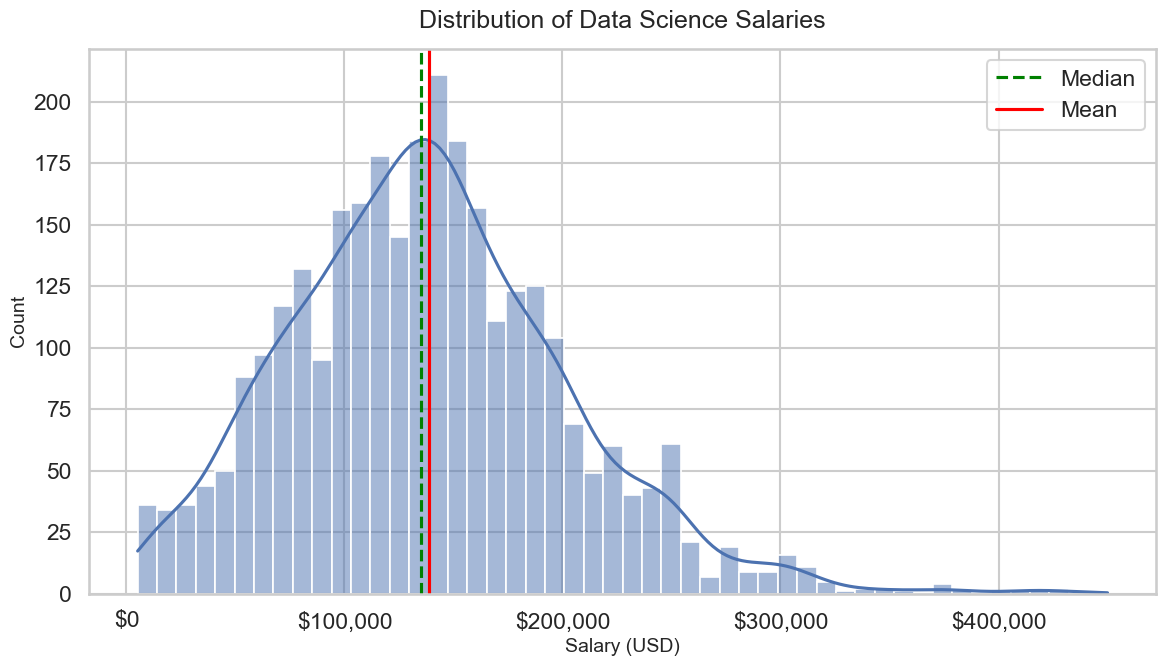

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# ヒストグラム
sns.histplot(
    data=train_df,
    x='salary_in_usd',
    bins=50,
    kde=True,    # 分布の形を分かりやすく（カーネル密度推定）
)

# 平均・中央値
mean_salary = train_df['salary_in_usd'].mean()
median_salary = train_df['salary_in_usd'].median()

plt.axvline(median_salary, linestyle='--', color='green', label='Median')
plt.axvline(mean_salary, linestyle='-', color='red', label='Mean')

# ドル＋カンマ
ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
)

# タイトルなど
plt.title('Distribution of Data Science Salaries', fontsize=18, pad=15)
plt.xlabel('Salary (USD)', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.legend()
plt.tight_layout()

# 保存（GitHub用）
plt.savefig('../images/histogram.png', dpi=300)

plt.show()

The salary distribution is right-skewed, with a small number of high-income individuals pulling the mean upward.

<Axes: xlabel='remote_ratio', ylabel='salary_in_usd'>

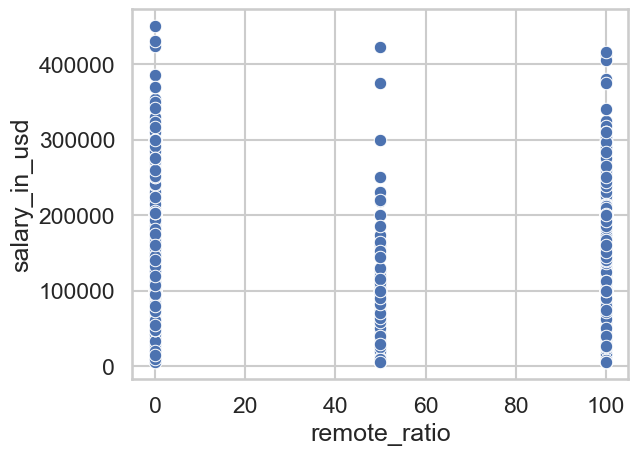

In [27]:
sns.scatterplot(
    x='remote_ratio', 
    y='salary_in_usd', 
    data=train_df, 
)